In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import pandas as pd


In [2]:
# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Define data paths
data_dir = 'Face Expression DataSet/Data'
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'testing')

In [4]:
# Define data transformations
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [5]:
# Load datasets
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)


C:\Users\yashp\AppData\Local\Temp\ipykernel_24016\3889313372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[train_dataset.classes[i] for i in classes], y=counts, palette="viridis")


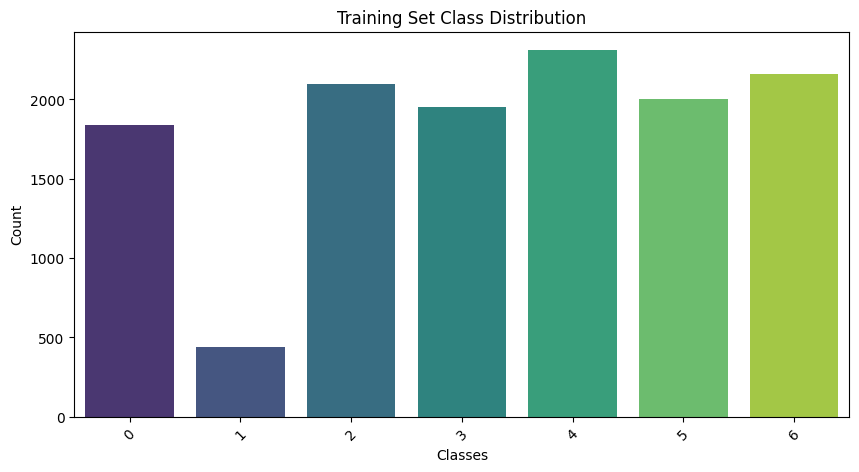

C:\Users\yashp\AppData\Local\Temp\ipykernel_24016\3889313372.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[train_dataset.classes[i] for i in classes], y=counts, palette="viridis")


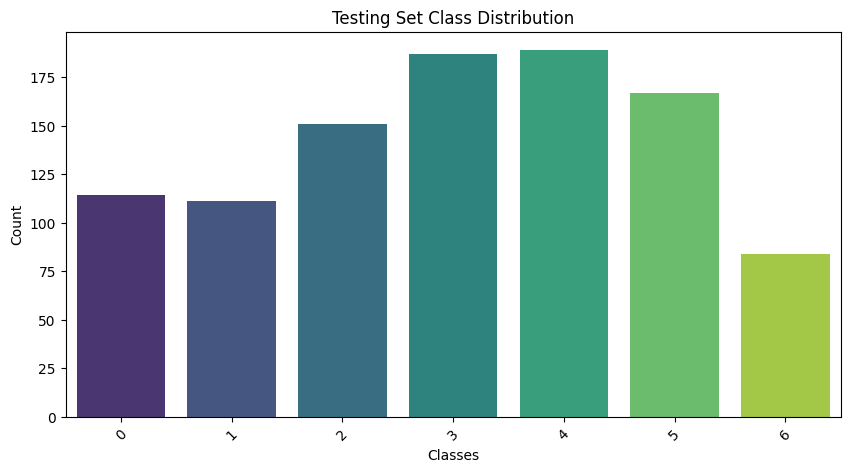

In [6]:
# Exploratory Data Analysis (EDA)
def plot_class_distribution(dataset, title):
    labels = [label for _, label in dataset]
    class_counts = Counter(labels)
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=[train_dataset.classes[i] for i in classes], y=counts, palette="viridis")
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

plot_class_distribution(train_dataset, "Training Set Class Distribution")
plot_class_distribution(test_dataset, "Testing Set Class Distribution")

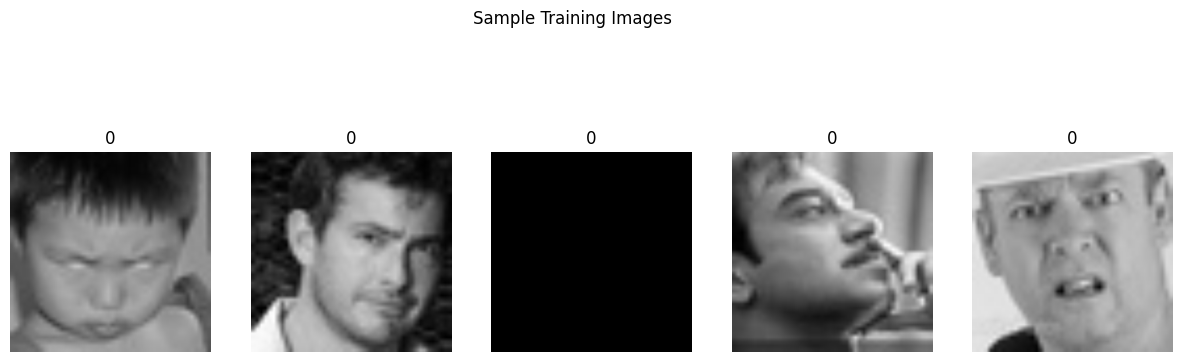

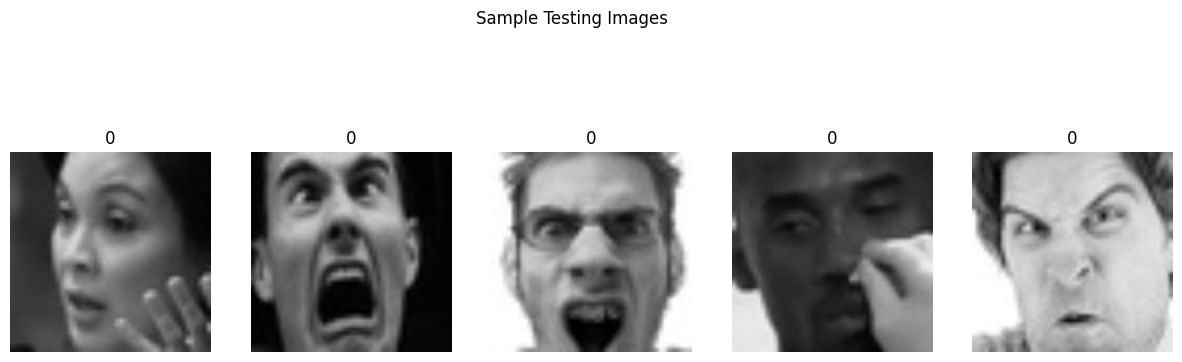

In [7]:
# Display some sample images
def show_sample_images(dataset, title, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image, label = dataset[i]
        image = image.permute(1, 2, 0).numpy() * 0.5 + 0.5  # Unnormalize
        axes[i].imshow(image)
        axes[i].set_title(train_dataset.classes[label])
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

show_sample_images(train_dataset, "Sample Training Images")
show_sample_images(test_dataset, "Sample Testing Images")


In [9]:
# Define data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [10]:
# Load Pretrained InceptionV3 model
model = models.inception_v3(init_weights=True)
print(model)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [11]:
# Modify the final layer for classification
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Modify auxiliary classifier
if model.aux_logits:
    model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)

model = model.to(device)
print(model)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [12]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [14]:
# Training loop
epochs = 30
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
precision_scores = []
recall_scores = []
f1_scores = []
confusion_matrices = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")
    for batch_idx, (images, labels) in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs, aux_outputs = model(images) if model.aux_logits else (model(images), None)
        loss = criterion(outputs, labels)
        if aux_outputs is not None:
            aux_loss = criterion(aux_outputs, labels)
            loss += 0.4 * aux_loss  # Auxiliary loss weighted at 0.4
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix(loss=running_loss / (batch_idx + 1), accuracy=100 * correct / total)
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs}, Training Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_acc:.2f}%", flush=True)
    
    

Epoch 1/30: 100%|██████████| 400/400 [02:06<00:00,  3.16it/s, accuracy=29.8, loss=2.45]

Epoch 1/30, Training Loss: 2.4529, Training Accuracy: 29.80%



Epoch 2/30: 100%|██████████| 400/400 [02:06<00:00,  3.16it/s, accuracy=43.2, loss=2.07]

Epoch 2/30, Training Loss: 2.0673, Training Accuracy: 43.21%



Epoch 3/30: 100%|██████████| 400/400 [02:06<00:00,  3.16it/s, accuracy=49, loss=1.86]  

...

Epoch 28/30, Training Loss: 0.1382, Training Accuracy: 96.33%



Epoch 29/30: 100%|██████████| 400/400 [02:04<00:00,  3.21it/s, accuracy=95.6, loss=0.173]

Epoch 29/30, Training Loss: 0.1730, Training Accuracy: 95.59%



Epoch 30/30: 100%|██████████| 400/400 [02:04<00:00,  3.21it/s, accuracy=97, loss=0.119]  

Epoch 30/30, Training Loss: 0.1193, Training Accuracy: 96.98%


In [16]:
    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
        
            outputs = model(images)
            if model.aux_logits and isinstance(outputs, tuple):
                outputs, _ = outputs  # Unpacking only if aux_logits is enabled
            
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    
    epoch_test_loss = test_loss / len(test_loader)
    epoch_test_acc = 100 * correct / total
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)
    
    # Calculate additional metrics
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)
    confusion_matrices.append(cm)
    
    print(f"Epoch {epoch+1}/{epochs}, Test Loss: {epoch_test_loss:.4f}, Test Accuracy: {epoch_test_acc:.2f}%")
  #  print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Epoch 30/30, Test Loss: 2.1802, Test Accuracy: 61.02%


In [17]:
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Precision: 0.6297, Recall: 0.6102, F1 Score: 0.6119


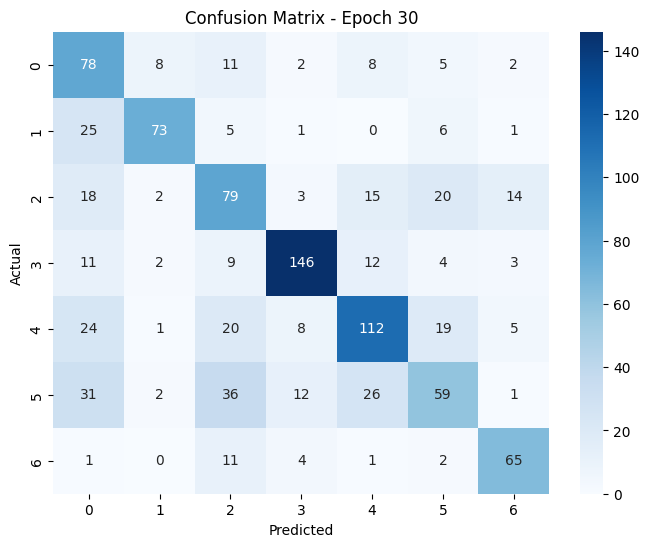

In [18]:
    # Plot confusion matrix
    df_cm = pd.DataFrame(cm, index=train_dataset.classes, columns=train_dataset.classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - Epoch {epoch+1}")
    plt.show()

In [19]:
# Save the trained model
torch.save(model.state_dict(), "emotion_model_inceptionv3_.pth")
print("Model training complete and saved.")

Model training complete and saved.


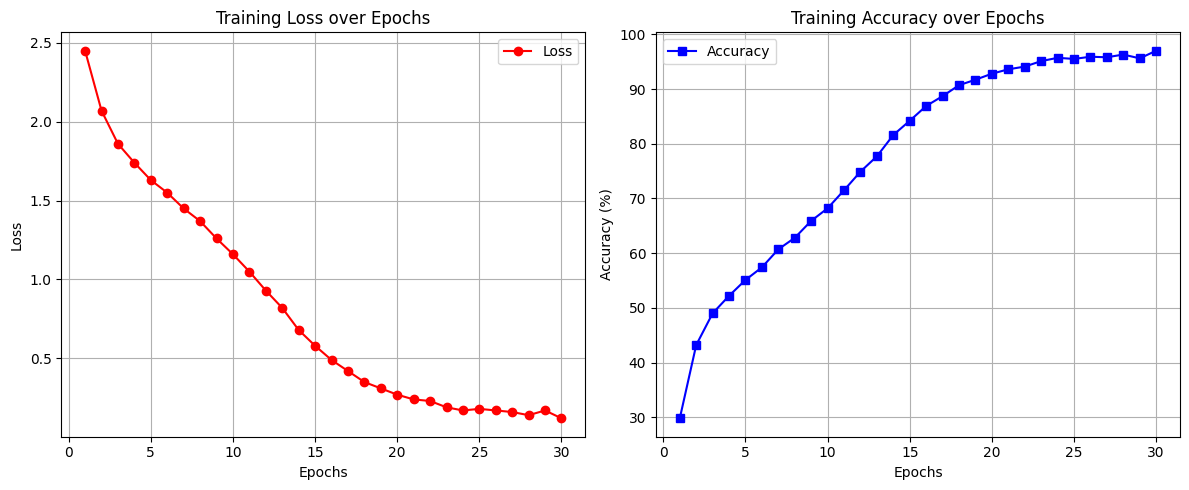

In [21]:
import matplotlib.pyplot as plt

# Training loss values
loss_values = [2.45, 2.07, 1.86, 1.74, 1.63, 1.55, 1.45, 1.37, 1.26, 1.16, 
               1.05, 0.93, 0.82, 0.68, 0.58, 0.49, 0.42, 0.35, 0.31, 0.27, 
               0.24, 0.23, 0.19, 0.17, 0.18, 0.17, 0.16, 0.14, 0.17, 0.12]

# Training accuracy values
accuracy_values = [29.8, 43.2, 49.0, 52.2, 55.1, 57.4, 60.7, 62.8, 65.9, 68.2, 
                   71.5, 74.9, 77.7, 81.6, 84.2, 86.9, 88.7, 90.7, 91.7, 92.8, 
                   93.6, 94.1, 95.1, 95.7, 95.5, 95.9, 95.8, 96.3, 95.6, 97.0]

epochs = list(range(1, 31))

# Plotting loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, marker='o', linestyle='-', color='r', label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid()

# Plotting accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, accuracy_values, marker='s', linestyle='-', color='b', label='Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy over Epochs')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

